# Class 9 (Module 3): Predicting Values with Machine Learning

## 1. Topic: Linear Regression, Gradient Descent, MSE & Feature Scaling

### আমরা যা যা কভার করব

* **Linear Regression:** কন্টিনিউয়াস নিউমেরিক্যাল ভ্যালু প্রেডিক্ট করার জন্য সবচেয়ে বেসিক এবং শক্তিশালী অ্যালগরিদম।
* **Gradient Descent:** এটি হলো সেই অপ্টিমাইজেশন ইঞ্জিন যা মডেলকে শেখায় কীভাবে ডেটা থেকে নির্ভুলভাবে শিখতে হয়।
* **Mean Squared Error (MSE):** একটি গাণিতিক "রুলার" বা মাপকাঠি যা মাপে আমাদের প্রেডিকশনগুলো আসলে কতটা ভুল।
* **Feature Scaling:** ডেটা প্রি-প্রসেসিংয়ের একটি ধাপ যা নিশ্চিত করে যে কোনো একটি ফিচার যেন অন্য ফিচারকে লার্নিং প্রসেসে অহেতুক ডমিনেট না করে।

সব মিলিয়ে, এই চারটি কনসেপ্ট হলো যেকোনো ইঞ্জিনিয়ারের জন্য **minimal viable toolkit** — হোক সেটা রেভিনিউ ফোরকাস্টিং, বাড়ির দাম নির্ধারণ বা এনার্জি কনজাম্পশন প্রেডিকশন।

> **এই নোটবুকটা কীভাবে ব্যবহার করবেন:** উপর থেকে নিচে এক এক করে সব সেল রান করুন (`Shift + Enter`)। প্রতিটা code cell-এর আগে একটা markdown cell আছে যেখানে **WHAT / WHY / ANALOGY** লেখা — আগে ওটা পড়ুন, তারপর কোড রান করুন।

## 2. এটি কেন AI Engineering-এর সাথে রিলেটেড

| ডোমেন | কানেকশন |
| --- | --- |
| **Predictive Systems** | বাস্তব জীবনের বেশিরভাগ AI অ্যাপ্লিকেশন শুরু হয় "একটি সংখ্যা প্রেডিক্ট" করার মাধ্যমে: যেমন সেলস ফোরকাস্ট বা প্রাইসিং ইঞ্জিন। লিনিয়ার রিগ্রেশন হলো এই সবকিছুর প্রবেশদ্বার। |
| **Model Interpretability** | ব্ল্যাক-বক্স নিউরাল নেটওয়ার্কের মতো না হয়ে, লিনিয়ার রিগ্রেশন স্পষ্টভাবে দেখায় কোন ফিচার প্রেডিকশনে কতটা প্রভাব ফেলছে। ফাইন্যান্স বা হেলথকেয়ারের মতো সেক্টরে এই ইন্টারপ্রিটেবিলিটি বাধ্যতামূলক। |
| **Feature Engineering Validation** | জটিল মডেল ব্যবহার করার আগে ইঞ্জিনিয়াররা লিনিয়ার রিগ্রেশনকে বেঞ্চমার্ক হিসেবে ব্যবহার করে। যদি একটি নিউরাল নেটওয়ার্ক ভালো টিউন করা লিনিয়ার মডেলকে হারাতে না পারে, তবে বুঝতে হবে সমস্যাটা ফিচারে, মডেলে নয়। |
| **Optimization Literacy** | গ্র্যাডিয়েন্ট ডিসেন্ট হলো সেই একই অ্যালগরিদম যা ডিপ লার্নিং বা রিকমেন্ডেশন সিস্টেম ট্রেইন করতে ব্যবহৃত হয়। এটি লিনিয়ার রিগ্রেশনে শিখলে পরবর্তীতে অ্যাডভান্সড টপিক বোঝা অনেক সহজ হয়। |
| **Production Data Pipelines** | প্রোডাকশনে ফিচারের স্কেলিং করাটা একদম অপরিহার্য। স্কেলিং ছাড়া মডেলগুলো প্রোডাকশনে গিয়ে চুপচাপ ভুল রেজাল্ট দিতে থাকে (fail silently) কারণ রিয়েল-ওয়ার্ল্ড ডেটা ডিস্ট্রিবিউশন বদলে যায়। |

> **LLM কানেকশন:** ChatGPT বা Claude ট্রেইন করার অ্যালগরিদমটা কিন্তু আজকে যেটা শিখছি সেটাই — loss বের করো, gradient বের করো, এক কদম নিচে নামো, রিপিট করো। পার্থক্য শুধু স্কেলে: এখানে ২টা প্যারামিটার, ওখানে ১৭৫ বিলিয়ন। প্রিন্সিপাল হুবহু এক।

## 3. How It Works: The Four Pillars

---

### Pillar 1: Linear Regression — Drawing the Best-Fit Line

লিনিয়ার রিগ্রেশন ধরে নেয় যে ইনপুট ফিচার ($X$) এবং টার্গেট ভ্যালু ($y$) এর মধ্যে একটি **linear relationship** বা সরলরৈখিক সম্পর্ক আছে।

$$\hat{y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_nX_n$$

* $\hat{y}$ = predicted value (মডেলের দেওয়া অনুমান)
* $\beta_0$ = intercept (সব ফিচার জিরো হলে বেসলাইন প্রেডিকশন)
* $\beta_1 \dots \beta_n$ = coefficients বা weights (প্রতিটি ফিচারের প্রভাবের মাত্রা)
* $X_1 \dots X_n$ = input features

**মডেলটি কীভাবে কাজ করে:** (১) random অনুমান দিয়ে শুরু, (২) প্রেডিকশন করা, (৩) ভুল মাপা, (৪) ভুল কমাতে $\beta$ অ্যাডজাস্ট করা, (৫) রিপিট।

---

### Pillar 2: Mean Squared Error (MSE) — Measuring Wrongness

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**কেন স্কয়ার করা হয়?**

* স্কয়ার করলে সব error **পজিটিভ** হয় (নেগেটিভ-পজিটিভ কাটাকাটি হয় না)।
* বড় ভুলের জন্য **বেশি শাস্তি** — ১ ভুলে পেনাল্টি ১, ১০ ভুলে পেনাল্টি ১০০।
* ফাংশনটি **smooth এবং differentiable** হয়, তাই gradient বের করা যায়।

---

### Pillar 3: Gradient Descent — শেখার মূল অ্যালগরিদম

কল্পনা করুন আপনি পাহাড়ের ওপর চোখে পট্টি বেঁধে দাঁড়িয়ে আছেন। পা দিয়ে মাটি অনুভব করে বুঝলেন কোন দিক ঢালু, সেদিকে এক কদম দিলেন। বারবার করতে করতে নিচে পৌঁছালেন।

$$\beta_{\text{new}} = \beta_{\text{old}} - \alpha \times \frac{\partial \text{MSE}}{\partial \beta}$$

* $\alpha$ = learning rate (একবারে কতটা বড় কদম)
* **খুব ছোট $\alpha$:** মডেল খুব ধীরে শেখে।
* **খুব বড় $\alpha$:** মিনিমাম পার হয়ে লাফিয়ে চলে যায় (overshoot), কখনো পৌঁছায় না।

---

### Pillar 4: Feature Scaling — প্রতিযোগিতার মাঠ সমান করা

গ্র্যাডিয়েন্ট ডিসেন্ট স্কেলিংয়ের প্রতি খুব sensitive। একটা ফিচার ১–১০,০০,০০০ আর আরেকটা ০–১ হলে বড় ফিচারের গ্র্যাডিয়েন্ট সব আপডেট ডমিনেট করবে।

**Standardization (Z-score):** $X_{\text{scaled}} = \dfrac{X - \mu}{\sigma}$ → mean ০, std ১।

**Min-Max Scaling:** $X_{\text{scaled}} = \dfrac{X - X_{\min}}{X_{\max} - X_{\min}}$ → রেঞ্জ [0, 1]।

> **Critical Rule:** টেস্ট ডেটার ওপর কখনো `fit_transform` করবেন না। স্কেলিং প্যারামিটার শুধু ট্রেনিং ডেটা থেকেই শিখবেন, তারপর ট্রেন ও টেস্ট দুই জায়গাতেই `transform` অ্যাপ্লাই করবেন। এই নোটবুকের Step 11-এ আমরা হাতে-কলমে দেখব ভুলটা করলে কী হয়।

## 4. You can think like this: একটি রোবটকে বাস্কেটবল থ্রো করা শেখানো

কল্পনা করুন, আপনি একটি রোবটকে বিভিন্ন দূরত্ব থেকে বাস্কেটবল হুপের ভেতরে বল ছুড়ে মারতে শেখাচ্ছেন।

### রোবটটি হলো = Linear Regression Model
* রোবটের **অ্যাডজাস্টেবল জয়েন্টস** (weights বা $\beta$ coefficients) তার হাতের অ্যাঙ্গেল ও ফোর্স কন্ট্রোল করে।
* **হুপের দূরত্ব** হলো ইনপুট ফিচার ($X$), **হুপের পজিশন** হলো টার্গেট ($y$)।

### MSE হলো = মাঠের স্কোরবোর্ড
* প্রতিবার থ্রোয়ের পর বলটি হুপ থেকে কত দূরে পড়ল, সেটা মেপে **স্কয়ার** করা হচ্ছে — ৩ মিটার মিসের শাস্তি ১ মিটার মিসের চেয়ে ৯ গুণ বেশি।

### Gradient Descent হলো = কোচের ফিডব্যাক
* কোচ বলছে: *"তোমার হাতের অ্যাঙ্গেল বেশি উপরে ছিল — পরের বার একটু নিচে নামাও।"*
* **লার্নিং রেট** = রোবট একবারে কতটা পরিবর্তন করছে। বেশি বড় স্টেপ = অতিরিক্ত অ্যাডজাস্ট করে উল্টো দিকে মিস।

### Feature Scaling হলো = কোর্ট স্ট্যান্ডার্ডাইজ করা
* রোবট **বাতাসের গতি** (0–30 km/h) আর **কোর্টের উচ্চতা** (0–3,000 m) দুটোই বিবেচনা করছে।
* স্কেলিং ছাড়া রোবট শুধু উচ্চতার বড় সংখ্যা নিয়ে পড়ে থাকবে, বাতাসকে পাত্তাই দেবে না — যদিও বাতাসই হয়তো বেশি ম্যাটার করত।

### Core Learning
> রোবটটি "বাস্কেটবল" বোঝে না। সে স্রেফ trial and error-এর মাধ্যমে এমন জয়েন্ট অ্যাঙ্গেল খুঁজে পেয়েছে যা স্কয়ারড error কমায়। লিনিয়ার রিগ্রেশনও তাই: সে আপনার বিজনেস বোঝে না — শুধু error মিনিমাইজ করে। **সঠিক ফিচার, সঠিক স্কেল আর সঠিক লস ফাংশন দেওয়াটা ইঞ্জিনিয়ারের দায়িত্ব।**

## 5. Detailed Breakdown: Assumptions ও Valid Points

### 5.1 Linear Regression Assumptions

| শর্ত | মানে কী | চেক করার উপায় | ভাঙলে কী হয় |
| --- | --- | --- | --- |
| **Linearity** | $X$ ও $y$-এর সম্পর্ক সরলরৈখিক | Residual plot (random নয়েজের মতো দেখাবে) | রেসিডুয়ালে বাঁকানো প্যাটার্ন = সিস্টেমেটিক বায়াস |
| **Independence** | একটি অবজারভেশন অন্যটিকে প্রভাবিত করে না | Durbin-Watson test; ডোমেইন নলেজ | মডেল নিজের প্রেডিকশনে অতিরিক্ত কনফিডেন্ট হয় |
| **Homoscedasticity** | সব $X$ জুড়ে error ভ্যারিয়েন্স কনস্ট্যান্ট | Residuals vs fitted plot (ফানেল শেপ = খারাপ) | হাইপোথিসিস টেস্ট আনরিলায়েবল |
| **Normality of Errors** | রেসিডুয়ালগুলো নরমালি ডিস্ট্রিবিউটেড | Q-Q plot, Shapiro-Wilk | p-value ও কনফিডেন্স ইন্টারভাল ইনভ্যালিড |
| **No Multicollinearity** | ফিচারগুলো নিজেদের মধ্যে পারফেক্টলি কোরিলেটেড নয় | VIF < ১০ | কো-এফিশিয়েন্ট এস্টিমেট আনস্টেবল |

> **Valid Point:** লিনিয়ার রিগ্রেশন কোনো "ডাম্ব" বেসলাইন নয় — এটি একটি **diagnostic tool**। ফেইল করলে সে স্পষ্ট বলে দেয় আপনার ডেটার কোথায় সমস্যা।

### 5.2 Gradient Descent-এর ভ্যারিয়েন্ট

| ভ্যারিয়েন্ট | যেভাবে কাজ করে | সেরা কীসের জন্য | ট্রেড-অফ |
| --- | --- | --- | --- |
| **Batch GD** | প্রতি স্টেপে *পুরো* ট্রেনিং ডেটা | ছোট ডেটাসেট (<10k rows) | স্লো স্টেপ, স্টেবল কনভার্জেন্স |
| **Stochastic GD** | প্রতি স্টেপে *একটি* random পয়েন্ট | বিশাল ডেটাসেট, অনলাইন লার্নিং | ফাস্ট স্টেপ, নয়েজি কনভার্জেন্স |
| **Mini-Batch GD** | প্রতি স্টেপে ৩২–৫১২ স্যাম্পল | ডিপ লার্নিং, লার্জ ট্যাবলার ডেটা | স্পিড ও স্টেবিলিটির ব্যালেন্স |

### 5.3 MSE কখন এড়িয়ে চলবেন

* **আউটলায়ার থাকলে:** একটি এক্সট্রিম আউটলায়ার পুরো লস ডমিনেট করতে পারে → **MAE** বেশি রোবাস্ট।
* **অ্যাসিম্যাট্রিক কস্ট:** ওভার-প্রেডিক্ট করা আন্ডার-প্রেডিক্টের চেয়ে বেশি ক্ষতিকর হলে (ইনভেন্টরি ফোরকাস্ট) কাস্টম লস লাগবে।
* **ক্ল্যাসিফিকেশনে:** MSE শুধু রিগ্রেশনের জন্য; ক্ল্যাসিফিকেশনে cross-entropy।

### 5.4 Complete Workflow

```
Raw Data
   │
   ▼  1. Data Cleaning & Splitting   → missing value, duplicate, train/val/test (70/15/15)
   ▼  2. Feature Scaling             → scaler ফিট শুধু train-এ, transform সবগুলোয়
   ▼  3. Model Training              → LinearRegression fit, validation MSE মনিটর
   ▼  4. Evaluation                  → MSE, RMSE, MAE, residual analysis
   ▼  5. Interpretation & Deployment → coefficient যাচাই, Pipeline-এ প্যাকেজ
```

## 6. Hands-On: Building a Price Predictor End-to-End

আমরা **Week 5 Class 1 Project**-এর সেই একই housing dataset ব্যবহার করব (৫,০০০ রেকর্ড, ১৬ ফিচার), যাতে নোটবুকে যা শিখলাম সেটা সরাসরি Streamlit dashboard-এ গিয়ে মিলিয়ে দেখতে পারেন।

**Analogy:** আমরা এখন সেই রোবটের কোচ। রোবটকে থ্রো করতে শেখাব, স্কোরবোর্ড দেখব, আর কোর্ট স্ট্যান্ডার্ডাইজ করব।

### 6.1 Setup & Imports

In [2]:
# =============================================================================
# CLASS 9: PREDICTING VALUES WITH MACHINE LEARNING
# =============================================================================
# Linear Regression + Gradient Descent + MSE + Feature Scaling, end to end.
# প্রতিটা সেকশনে: WHAT (কী করছি), WHY (কেন), HOW (কীভাবে)।
# =============================================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# একই random seed = প্রতিবার একই রেজাল্ট। ক্লাসে সবার স্ক্রিনে একই সংখ্যা আসবে।
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Setup complete. numpy", np.__version__, "| pandas", pd.__version__)

Setup complete. numpy 2.5.2 | pandas 3.0.5


### 6.2 Data Loading

**What we do:** Class 1 Project-এর `housing_data.csv` লোড করি।

**Why:** মডেল ছোঁয়ার আগে ডেটা চিনতে হবে — কয়টা row, কয়টা column, কোন টাইপ, missing আছে কি না।

**Analogy:** রোবটকে মাঠে নামানোর আগে কোচ মাঠের মাপ আর বাতাসের অবস্থা দেখে নিচ্ছে।

In [3]:
# ---------------------------------------------------------------------------
# STEP 1: LOAD DATA
# ---------------------------------------------------------------------------
# নোটবুকটা যেখান থেকেই রান করুন, ফাইলটা খুঁজে নেবে।
CANDIDATES = [
    Path("../Class 1 Project/data/housing_data.csv"),
    Path("week 5/Class 1 Project/data/housing_data.csv"),
    Path("Class 1 Project/data/housing_data.csv"),
]
data_file = next((p for p in CANDIDATES if p.exists()), None)

if data_file is None:
    # CSV না পেলে একই আকারের synthetic ডেটা বানিয়ে নিই, যাতে নোটবুক কখনো আটকে না যায়।
    print("housing_data.csv পাওয়া যায়নি — synthetic fallback ব্যবহার করছি।")
    n = 5000
    rng = np.random.default_rng(RANDOM_STATE)
    df = pd.DataFrame({
        "median_income": rng.uniform(1.5, 13, n).round(2),
        "house_age": rng.integers(1, 52, n),
        "avg_rooms": rng.uniform(2, 10, n).round(1),
        "avg_bedrooms": rng.uniform(0.5, 3, n).round(1),
        "population": rng.integers(100, 35000, n),
        "avg_occupancy": rng.uniform(0.5, 7, n).round(2),
        "latitude": rng.uniform(32.5, 42, n).round(2),
        "longitude": rng.uniform(-124.5, -114, n).round(2),
        "lot_size_sqft": rng.uniform(1000, 50000, n).round(0),
        "garage_spaces": rng.integers(0, 5, n),
        "has_pool": rng.integers(0, 2, n),
        "has_basement": rng.integers(0, 2, n),
        "distance_to_city": rng.uniform(0, 80, n).round(1),
        "school_rating": rng.integers(1, 11, n),
        "property_tax_rate": rng.uniform(0.5, 2.5, n).round(2),
    })
    df["year_built"] = 2024 - df["house_age"]
    df["price"] = (
        40481 * df["median_income"] + 24335 * df["has_pool"] + 14940 * df["avg_rooms"]
        + 13589 * df["has_basement"] + 8457 * df["garage_spaces"] + 5021 * df["school_rating"]
        - 770 * df["distance_to_city"] - 191355 + rng.normal(0, 22000, n)
    ).round(2)
else:
    df = pd.read_csv(data_file)
    print("Loaded:", data_file)

print("Shape:", df.shape)
df.head()

Loaded: ../Class 1 Project/data/housing_data.csv
Shape: (5000, 17)


,price,median_income,house_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,lot_size_sqft,garage_spaces,has_pool,has_basement,distance_to_city,school_rating,property_tax_rate,year_built
0,"272,800.1400",3.3200,40,5.7000,0.8000,1882,3.1200,37.2200,-114.0600,"1,536.0000",3,0,1,18.2000,6,1.2400,1984
1,"225,760.2300",2.5700,1,1.3000,1.4000,1308,3.1900,39.6300,-116.2400,"1,622.0000",2,0,0,4.4000,7,0.8800,2023
2,"230,403.6800",3.5200,4,3.4000,1.2000,1328,2.9200,36.5600,-115.5200,"4,127.0000",2,1,0,53.0000,3,1.3400,2020
3,"293,804.3100",5.0000,30,6.9000,1.0000,1294,1.9800,32.5300,-118.2800,"2,194.0000",2,0,0,20.6000,1,1.0800,1994
4,"221,936.1200",2.4800,12,4.3000,0.3000,433,0.7200,38.3100,-120.8400,"5,582.0000",4,0,0,5.3000,4,1.2100,2012


### 6.3 Data Understanding

**What we do:** shape, dtype, missing value আর target-এর সাথে correlation দেখি।

**Why:** correlation বলে দেয় কোন ফিচারগুলো আদৌ price-এর সাথে সম্পর্কিত। যেগুলোর correlation প্রায় শূন্য, তারা মডেলে বসে থাকবে কিন্তু কিছু দেবে না।

**Analogy:** কোচ আগে দেখে নিচ্ছে কোন কোন ভ্যারিয়েবল আসলে থ্রোয়ের ফলাফল বদলায় — বাতাস বদলায়, কিন্তু দর্শকের শার্টের রঙ বদলায় না।

In [4]:
# ---------------------------------------------------------------------------
# STEP 2: UNDERSTAND THE DATA
# ---------------------------------------------------------------------------
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print()
print("Target (price) summary:")
print(df["price"].describe()[["mean", "std", "min", "50%", "max"]])
print()

# price-এর সাথে প্রতিটা ফিচারের correlation, শক্তি অনুযায়ী সাজানো
corr = df.corr(numeric_only=True)["price"].drop("price")
corr_table = pd.DataFrame({
    "correlation": corr,
    "strength": np.select(
        [corr.abs() > 0.5, corr.abs() > 0.3],
        ["Strong", "Moderate"],
        default="Weak",
    ),
}).sort_values("correlation", key=abs, ascending=False)
print("Correlation with price:")
print(corr_table)

Missing values: 0
Duplicate rows: 0

Target (price) summary:
mean   277,566.0742
std     63,273.7522
min     76,624.6200
50%    270,138.5250
max    757,666.0100
Name: price, dtype: float64

Correlation with price:
                   correlation  strength
median_income           0.7887    Strong
avg_rooms               0.3602  Moderate
distance_to_city       -0.1708      Weak
has_pool                0.1708      Weak
school_rating           0.1641      Weak
garage_spaces           0.1400      Weak
has_basement            0.1200      Weak
lot_size_sqft           0.0677      Weak
year_built              0.0417      Weak
house_age              -0.0417      Weak
population             -0.0142      Weak
property_tax_rate       0.0120      Weak
latitude               -0.0051      Weak
avg_bedrooms            0.0013      Weak
longitude               0.0013      Weak
avg_occupancy           0.0005      Weak


### 6.4 Single-Feature Intuition — একটা লাইন বসানো

**What we do:** শুধু `median_income` বনাম `price` নিয়ে একটা scatter plot করি, আর হাতে বসানো তিনটা আলাদা লাইন আঁকি।

**Why:** ১৬টা ফিচার একসাথে ভিজুয়ালাইজ করা যায় না। কিন্তু একটা ফিচারে পুরো আইডিয়াটা চোখে দেখা যায়: **লিনিয়ার রিগ্রেশন মানে হলো সবচেয়ে ভালো লাইনটা খুঁজে বের করা।**

**Analogy:** রোবটের হাতের তিনটা আলাদা অ্যাঙ্গেল ট্রাই করে দেখা — কোনটায় বল হুপের সবচেয়ে কাছে যায়।

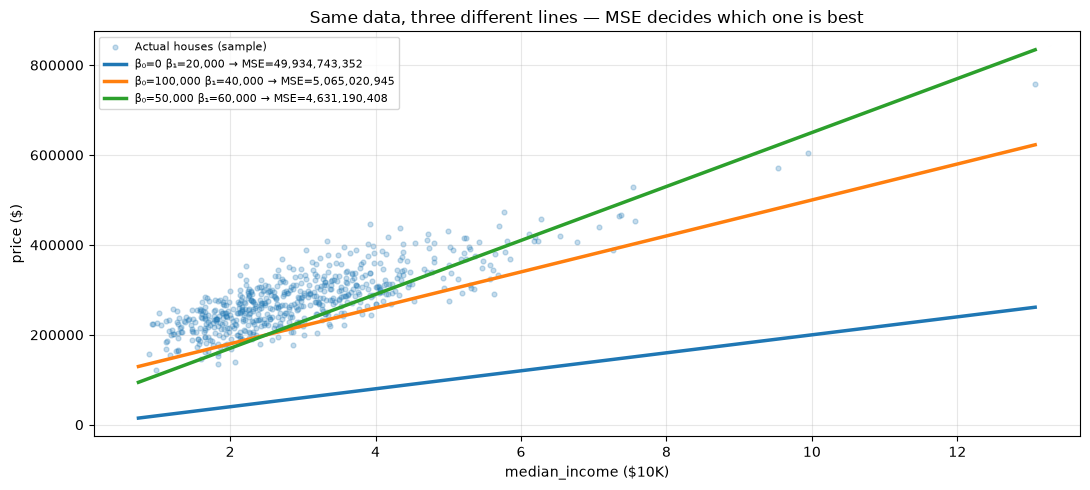

In [5]:
# ---------------------------------------------------------------------------
# STEP 3: ONE FEATURE, THREE GUESSES
# ---------------------------------------------------------------------------
x = df["median_income"].values
y = df["price"].values

# তিনটা হাতে বসানো (β₀, β₁) — কোনটা ভালো, সেটা চোখে নয়, MSE দিয়ে ঠিক হবে
guesses = [(0, 20000), (100000, 40000), (50000, 60000)]

sample = np.random.default_rng(RANDOM_STATE).choice(len(x), 600, replace=False)
grid = np.linspace(x.min(), x.max(), 50)

plt.figure(figsize=(11, 5))
plt.scatter(x[sample], y[sample], alpha=0.25, s=12, label="Actual houses (sample)")
for b0, b1 in guesses:
    mse_guess = np.mean((y - (b0 + b1 * x)) ** 2)
    plt.plot(grid, b0 + b1 * grid, linewidth=2.5,
             label=f"β₀={b0:,} β₁={b1:,} → MSE={mse_guess:,.0f}")
plt.xlabel("median_income ($10K)")
plt.ylabel("price ($)")
plt.title("Same data, three different lines — MSE decides which one is best")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6.5 MSE — ভুল মাপার রুলার

**What we do:** $\beta_1$-এর অনেকগুলো ভ্যালুর জন্য MSE হিসাব করে plot করি ($\beta_0$ ফিক্সড রেখে)।

**Why:** এই একটা ছবি পুরো gradient descent-এর ভিত্তি। MSE কার্ভটা একটা **parabola** — এর একটাই তলা (global minimum) আছে। মডেলের পুরো কাজ হলো ওই তলাটা খুঁজে বের করা।

**Analogy:** এটাই সেই "পাহাড়"। রোবট এখন চোখে পট্টি বেঁধে এই কার্ভের তলায় নামবে।

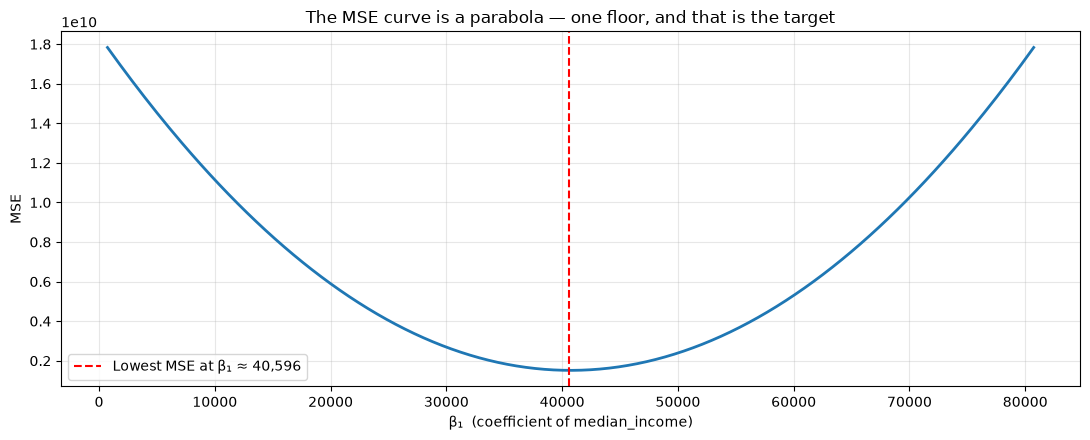

Grid search-এ পাওয়া best β₁ = 40,596  (MSE = 1,513,207,872)
scikit-learn OLS-এর উত্তর      = 40,730
৩০০টা ভ্যালু ট্রাই করে আমরা প্রায় একই জায়গায় পৌঁছেছি। কিন্তু —

এই brute-force grid search ১টা প্যারামিটারে কাজ করে।
১৬টা প্যারামিটারে? প্রতিটায় ৩০০ ভ্যালু হলে 300^16 কম্বিনেশন — অসম্ভব।
তাই gradient descent দরকার।


In [6]:
# ---------------------------------------------------------------------------
# STEP 4: THE MSE CURVE — the hill our model must walk down
# ---------------------------------------------------------------------------
def mse(y_true, y_pred):
    '''MSE হাতে লিখলাম — সূত্রটা যেন রহস্য না থাকে: গড় স্কয়ারড ভুল।'''
    return np.mean((y_true - y_pred) ** 2)

# একটা ফিচারের সেরা লাইনটা আগে বের করে নিই, তারপর β₀ ওখানে ফিক্সড রেখে
# শুধু β₁ ঘোরাই — তাহলে ছবিটা এক মাত্রায় আঁকা যায়।
single = LinearRegression().fit(x.reshape(-1, 1), y)
B0_FIXED = single.intercept_
best_known = single.coef_[0]

beta1_grid = np.linspace(best_known - 40000, best_known + 40000, 300)
mse_curve = [mse(y, B0_FIXED + b1 * x) for b1 in beta1_grid]

best_idx = int(np.argmin(mse_curve))
best_b1 = beta1_grid[best_idx]

plt.figure(figsize=(11, 4.5))
plt.plot(beta1_grid, mse_curve, linewidth=2)
plt.axvline(best_b1, color="red", linestyle="--",
            label=f"Lowest MSE at β₁ ≈ {best_b1:,.0f}")
plt.xlabel("β₁  (coefficient of median_income)")
plt.ylabel("MSE")
plt.title("The MSE curve is a parabola — one floor, and that is the target")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Grid search-এ পাওয়া best β₁ = {best_b1:,.0f}  (MSE = {min(mse_curve):,.0f})")
print(f"scikit-learn OLS-এর উত্তর      = {best_known:,.0f}")
print("৩০০টা ভ্যালু ট্রাই করে আমরা প্রায় একই জায়গায় পৌঁছেছি। কিন্তু —")
print()
print("এই brute-force grid search ১টা প্যারামিটারে কাজ করে।")
print("১৬টা প্যারামিটারে? প্রতিটায় ৩০০ ভ্যালু হলে 300^16 কম্বিনেশন — অসম্ভব।")
print("তাই gradient descent দরকার।")

### 6.6 Gradient Descent — একদম স্ক্র্যাচ থেকে

**What we do:** নিজের হাতে gradient descent লিখি — কোনো sklearn নয়, শুধু numpy।

**Why:** `model.fit()` লিখলে ভেতরে কী হচ্ছে সেটা লুকিয়ে যায়। একবার নিজে লিখলে আর কখনো এটা ম্যাজিক মনে হবে না। এই একই লুপ দিয়েই GPT ট্রেইন হয়।

**HOW — gradient-এর সূত্র:**

$$\frac{\partial \text{MSE}}{\partial \beta_0} = \frac{2}{n}\sum(\hat{y}_i - y_i) \qquad
\frac{\partial \text{MSE}}{\partial \beta_1} = \frac{2}{n}\sum(\hat{y}_i - y_i)\,x_i$$

> **খেয়াল করুন:** এখানে আমরা **standardized** $x$ আর $y$ ব্যবহার করছি। কেন — সেটা Step 7-এ হাতে-কলমে দেখব।

In [7]:
# ---------------------------------------------------------------------------
# STEP 5: GRADIENT DESCENT FROM SCRATCH
# ---------------------------------------------------------------------------
# Analogy: চোখে পট্টি বাঁধা রোবট। প্রতি স্টেপে সে শুধু ঢালটা অনুভব করে,
# আর ঢালের উল্টো দিকে এক কদম নামে।
# ---------------------------------------------------------------------------

def gradient_descent(x, y, learning_rate=0.1, n_iterations=100):
    '''একটা ফিচারের জন্য β₀ ও β₁ শেখে। history ফেরত দেয় যাতে পথটা আঁকা যায়।'''
    b0, b1 = 0.0, 0.0          # STEP 1: শুরু শূন্য থেকে
    n = len(x)
    history = []

    for i in range(n_iterations):
        y_hat = b0 + b1 * x                      # STEP 2: প্রেডিক্ট
        error = y_hat - y                        # (ŷ - y), residual-এর উল্টো সাইন
        current_mse = np.mean(error ** 2)        # STEP 3: ভুল মাপা
        history.append({"iteration": i, "b0": b0, "b1": b1, "mse": current_mse})

        grad_b0 = (2 / n) * np.sum(error)        # STEP 4: gradient
        grad_b1 = (2 / n) * np.sum(error * x)

        # গ্র্যাডিয়েন্ট বেড়ে গিয়ে inf হয়ে গেলে থামি, নাহলে NaN ছড়িয়ে পড়ে
        if not np.isfinite(grad_b0) or not np.isfinite(grad_b1):
            break

        b0 -= learning_rate * grad_b0            # STEP 5: আপডেট
        b1 -= learning_rate * grad_b1
                                                 # STEP 6: রিপিট
    return b0, b1, pd.DataFrame(history)


# ফিচার আর টার্গেট দুটোই standardize করে নিই
x_std = (x - x.mean()) / x.std()
y_std = (y - y.mean()) / y.std()

b0_gd, b1_gd, hist = gradient_descent(x_std, y_std, learning_rate=0.1, n_iterations=100)

print(f"Gradient descent শিখল : β₀ = {b0_gd:.6f}, β₁ = {b1_gd:.6f}")
print(f"Final MSE (standardized units) = {hist['mse'].iloc[-1]:.6f}")
print()
print("প্রথম ৫ ও শেষ ৩ ইটারেশন:")
print(pd.concat([hist.head(5), hist.tail(3)]))

Gradient descent শিখল : β₀ = -0.000000, β₁ = 0.788673
Final MSE (standardized units) = 0.377995

প্রথম ৫ ও শেষ ৩ ইটারেশন:
    iteration      b0     b1    mse
0           0  0.0000 0.0000 1.0000
1           1 -0.0000 0.1577 0.7761
2           2 -0.0000 0.2839 0.6328
3           3 -0.0000 0.3849 0.5410
4           4 -0.0000 0.4656 0.4824
97         97 -0.0000 0.7887 0.3780
98         98 -0.0000 0.7887 0.3780
99         99 -0.0000 0.7887 0.3780


**এখন যাচাই করি:** আমাদের হাতে-লেখা কোডটা কি scikit-learn-এর সাথে মেলে?

Scikit-Learn গ্র্যাডিয়েন্ট ডিসেন্ট ব্যবহারই করে না — সে **Normal Equation** ($\beta = (X^TX)^{-1}X^Ty$) দিয়ে সরাসরি exact উত্তর বের করে। দুটো পথ আলাদা, গন্তব্য এক। এটাই আমাদের কোড ঠিক আছে কি না তার প্রমাণ।

আমাদের GD        : β₀ = -0.000000, β₁ =  0.788673
scikit-learn OLS : β₀ = -0.000000, β₁ =  0.788673
পার্থক্য          : 0.00000000

✅ দুই পথে একই উত্তর। আমাদের gradient descent সঠিক।


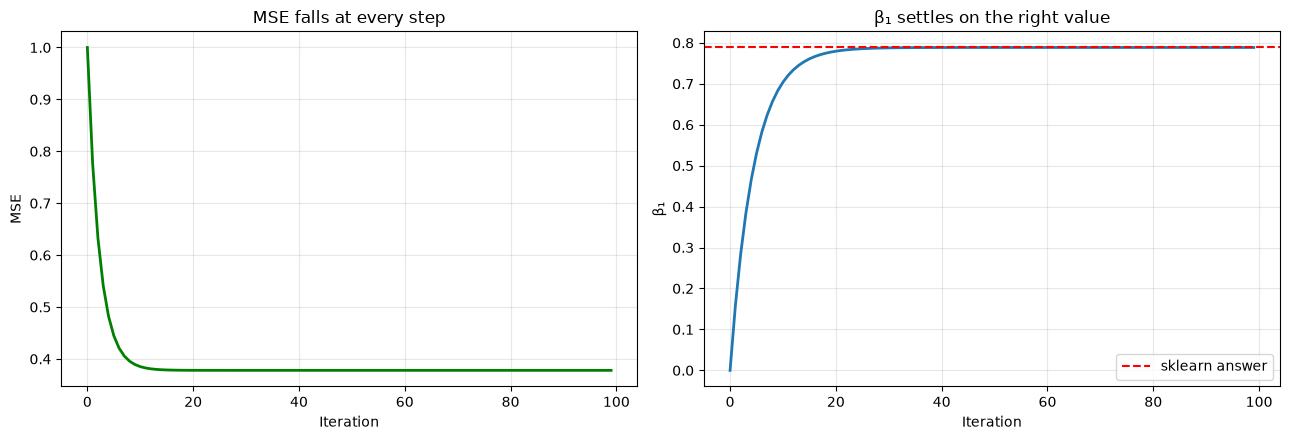

In [8]:
# ---------------------------------------------------------------------------
# VERIFY: hand-written GD vs scikit-learn's closed-form solution
# ---------------------------------------------------------------------------
sk_check = LinearRegression().fit(x_std.reshape(-1, 1), y_std)

print(f"আমাদের GD        : β₀ = {b0_gd: .6f}, β₁ = {b1_gd: .6f}")
print(f"scikit-learn OLS : β₀ = {sk_check.intercept_: .6f}, β₁ = {sk_check.coef_[0]: .6f}")
print(f"পার্থক্য          : {abs(b1_gd - sk_check.coef_[0]):.8f}")
assert abs(b1_gd - sk_check.coef_[0]) < 1e-4, "GD মেলেনি — learning rate বা iteration বাড়ান"
print("\n✅ দুই পথে একই উত্তর। আমাদের gradient descent সঠিক।")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hist["iteration"], hist["mse"], linewidth=2, color="green")
axes[0].set(xlabel="Iteration", ylabel="MSE", title="MSE falls at every step")
axes[1].plot(hist["iteration"], hist["b1"], linewidth=2)
axes[1].axhline(sk_check.coef_[0], color="red", linestyle="--", label="sklearn answer")
axes[1].set(xlabel="Iteration", ylabel="β₁", title="β₁ settles on the right value")
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.7 Learning Rate ($\alpha$) — তিনটা আচরণ

**What we do:** একই ডেটায় ভিন্ন ভিন্ন learning rate দিয়ে GD চালাই।

**Why:** $\alpha$ হলো gradient descent-এর একমাত্র সবচেয়ে গুরুত্বপূর্ণ knob। ভুল $\alpha$ দিলে মডেল হয় কচ্ছপের গতিতে শিখবে, নয়তো একদম বিস্ফোরিত হবে।

**Analogy:** কোচের ফিডব্যাক রোবট কতটা মেনে নিচ্ছে। ফিসফিস করে বললে (ছোট $\alpha$) রোবট নড়েই না; চিৎকার করলে (বড় $\alpha$) রোবট অতিরিক্ত অ্যাডজাস্ট করে বল মাঠের বাইরে মারে।

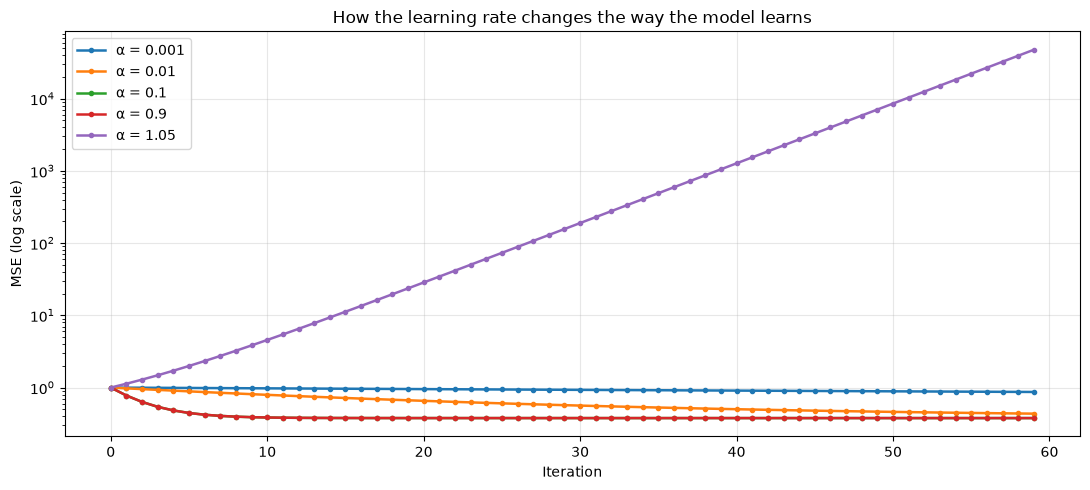

 learning_rate   final_mse  final_b1          verdict
        0.0010      0.8691    0.0893 🐢 এখনো শেখা বাকি
        0.0100      0.4353    0.5540 🐢 এখনো শেখা বাকি
        0.1000      0.3780    0.7887      ✅ converged
        0.9000      0.3780    0.7887      ✅ converged
        1.0500 47,657.8307 -239.3478       💥 diverged

এই ডেটায় optimal β₁ = 0.7887, আর MSE-র মেঝে = 0.3780
MSE কখনো ০ হয় না — নয়েজটুকু কোনো মডেলই ব্যাখ্যা করতে পারে না।
তাই converged কি না সেটা MSE দেখে নয়, β₁ সঠিক জায়গায় থামল কি না দেখে বিচার করছি।


In [9]:
# ---------------------------------------------------------------------------
# STEP 6: LEARNING RATE EXPERIMENT
# ---------------------------------------------------------------------------
rates = [0.001, 0.01, 0.1, 0.9, 1.05]

plt.figure(figsize=(11, 5))
summary = []
for lr in rates:
    _, b1_end, h = gradient_descent(x_std, y_std, learning_rate=lr, n_iterations=60)
    finite = h[np.isfinite(h["mse"])]
    plt.plot(finite["iteration"], finite["mse"], marker="o", markersize=3,
             linewidth=1.8, label=f"α = {lr}")
    optimal_b1 = sk_check.coef_[0]
    verdict = ("💥 diverged" if not np.isfinite(b1_end) or abs(b1_end) > 10
               else "✅ converged" if abs(b1_end - optimal_b1) < 0.01
               else "🐢 এখনো শেখা বাকি")
    summary.append({"learning_rate": lr, "final_mse": h["mse"].iloc[-1],
                    "final_b1": b1_end, "verdict": verdict})

plt.yscale("log")   # diverging রান কয়েক অর্ডার ম্যাগনিচিউড জুড়ে যায়
plt.xlabel("Iteration")
plt.ylabel("MSE (log scale)")
plt.title("How the learning rate changes the way the model learns")
plt.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame(summary).to_string(index=False))
print(f"\nএই ডেটায় optimal β₁ = {sk_check.coef_[0]:.4f}, আর MSE-র মেঝে = {1 - sk_check.coef_[0]**2:.4f}")
print("MSE কখনো ০ হয় না — নয়েজটুকু কোনো মডেলই ব্যাখ্যা করতে পারে না।")
print("তাই converged কি না সেটা MSE দেখে নয়, β₁ সঠিক জায়গায় থামল কি না দেখে বিচার করছি।")

### 6.8 Feature Scaling — কেন এটা অপশনাল নয়

**What we do:** **হুবহু একই** gradient descent কোড দুবার চালাই — একবার raw `median_income`-এ, একবার standardized-এ।

**Why:** এটাই আজকের সবচেয়ে গুরুত্বপূর্ণ ডেমো। স্কেলিং কোনো "সাজসজ্জা" নয় — unscaled ডেটায় একই $\alpha$ একদম বিস্ফোরিত হয়ে যায়। গ্র্যাডিয়েন্টের সাইজ সরাসরি ফিচারের সাইজের সাথে বাড়ে।

**Analogy:** কোর্টের উচ্চতা মিটারে (0–3000) আর বাতাস km/h-তে (0–30)। রোবট শুধু বড় সংখ্যাটাই "শুনতে" পায়।

একই কোড, একই α = 0.1, শুধু ফিচারের স্কেল আলাদা:

  RAW x     (range 0.7 – 13.1) → final MSE = 5.976e+08
  SCALED x  (mean 0, std 1)     → final MSE = 0.377995

ব্যাখ্যা: gradient-এ x গুণ হয়। x বড় হলে gradient বড় হয়, স্টেপ বড় হয়,
মডেল মিনিমাম পার হয়ে আরও দূরে ছিটকে যায় — প্রতি স্টেপে আরও দূরে।


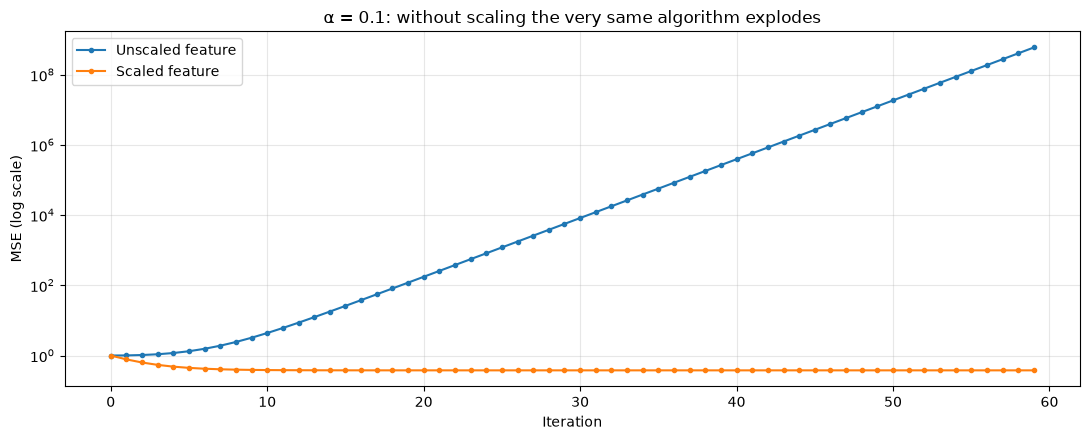

In [10]:
# ---------------------------------------------------------------------------
# STEP 7: THE SCALING DEMO — same code, same α, two different worlds
# ---------------------------------------------------------------------------
ALPHA = 0.1
y_for_demo = (y - y.mean()) / y.std()     # target দুই ক্ষেত্রেই একই রাখলাম

_, b1_raw, hist_raw = gradient_descent(x, y_for_demo, ALPHA, 60)          # raw x (1.5–13)
_, b1_scaled, hist_scaled = gradient_descent(x_std, y_for_demo, ALPHA, 60)  # scaled x

print(f"একই কোড, একই α = {ALPHA}, শুধু ফিচারের স্কেল আলাদা:\n")
print(f"  RAW x     (range {x.min():.1f} – {x.max():.1f}) → final MSE = {hist_raw['mse'].iloc[-1]:.3e}")
print(f"  SCALED x  (mean 0, std 1)     → final MSE = {hist_scaled['mse'].iloc[-1]:.6f}")
print()
print("ব্যাখ্যা: gradient-এ x গুণ হয়। x বড় হলে gradient বড় হয়, স্টেপ বড় হয়,")
print("মডেল মিনিমাম পার হয়ে আরও দূরে ছিটকে যায় — প্রতি স্টেপে আরও দূরে।")

plt.figure(figsize=(11, 4.5))
plt.plot(hist_raw["iteration"], hist_raw["mse"], marker="o", markersize=3, label="Unscaled feature")
plt.plot(hist_scaled["iteration"], hist_scaled["mse"], marker="o", markersize=3, label="Scaled feature")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("MSE (log scale)")
plt.title(f"α = {ALPHA}: without scaling the very same algorithm explodes")
plt.legend()
plt.tight_layout()
plt.show()

### 6.9 StandardScaler বনাম MinMaxScaler

**What we do:** scikit-learn-এর দুটো scaler একই ফিচারে লাগিয়ে ফলাফল তুলনা করি।

**Why:** কখন কোনটা — এই সিদ্ধান্তটা প্রোডাকশনে বারবার নিতে হয়।

| Scaler | সূত্র | ফলাফল | কখন |
| --- | --- | --- | --- |
| **StandardScaler** | $(x-\mu)/\sigma$ | mean 0, std 1 | ডিফল্ট চয়েস; gradient descent; আউটলায়ার থাকলে |
| **MinMaxScaler** | $(x-\min)/(\max-\min)$ | [0, 1] | বাউন্ডেড রেঞ্জ লাগলে (কিছু neural net activation) |

In [11]:
# ---------------------------------------------------------------------------
# STEP 8: TWO SCALERS, SIDE BY SIDE
# ---------------------------------------------------------------------------
demo_cols = ["median_income", "lot_size_sqft", "school_rating"]
standard = StandardScaler().fit_transform(df[demo_cols])
minmax = MinMaxScaler().fit_transform(df[demo_cols])

comparison = pd.DataFrame({
    "feature": demo_cols,
    "raw_min": df[demo_cols].min().values,
    "raw_max": df[demo_cols].max().values,
    "standard_mean": standard.mean(axis=0),
    "standard_std": standard.std(axis=0),
    "minmax_min": minmax.min(axis=0),
    "minmax_max": minmax.max(axis=0),
})
print(comparison.to_string(index=False))
print()
print("StandardScaler → mean সবসময় 0, std সবসময় 1 (রেঞ্জ যাই হোক)।")
print("MinMaxScaler   → min সবসময় 0, max সবসময় 1।")
print()
print("লক্ষ্য করুন lot_size_sqft raw অবস্থায় school_rating-এর চেয়ে হাজার গুণ বড়,")
print("কিন্তু scaling-এর পর দুজনেই একই মাঠে খেলছে।")

      feature  raw_min     raw_max  standard_mean  standard_std  minmax_min  minmax_max
median_income   0.7400     13.0700        -0.0000        1.0000      0.0000      1.0000
lot_size_sqft 516.0000 17,804.0000        -0.0000        1.0000      0.0000      1.0000
school_rating   1.0000     10.0000         0.0000        1.0000      0.0000      1.0000

StandardScaler → mean সবসময় 0, std সবসময় 1 (রেঞ্জ যাই হোক)।
MinMaxScaler   → min সবসময় 0, max সবসময় 1।

লক্ষ্য করুন lot_size_sqft raw অবস্থায় school_rating-এর চেয়ে হাজার গুণ বড়,
কিন্তু scaling-এর পর দুজনেই একই মাঠে খেলছে।


### 6.10 Train-Test Split — সততার পরীক্ষা

**What we do:** ডেটা ৮০/২০ ভাগ করি।

**Why:** যে ডেটা দেখে মডেল শিখেছে, সেই ডেটাতেই তাকে পরীক্ষা করলে সেটা মুখস্থবিদ্যার পরীক্ষা — generalization-এর নয়।

**Analogy:** রোবট যে ১০০টা থ্রো প্র্যাকটিস করেছে, ফাইনাল পরীক্ষা সেই থ্রোগুলোতে নয় — নতুন দূরত্ব থেকে।

In [12]:
# ---------------------------------------------------------------------------
# STEP 9: TRAIN-TEST SPLIT
# ---------------------------------------------------------------------------
feature_names = [c for c in df.columns if c != "price"]
X = df[feature_names]
y_all = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_all, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows   ({X_train.shape[0]/len(df):.0%})")
print(f"Test : {X_test.shape[0]:,} rows   ({X_test.shape[0]/len(df):.0%})")
print(f"Features: {len(feature_names)}")
print()
print("random_state=42 → প্রতিবার হুবহু একই split। রেজাল্ট রিপ্রোডিউসিবল রাখার শর্ত।")

Train: 4,000 rows   (80%)
Test : 1,000 rows   (20%)
Features: 16

random_state=42 → প্রতিবার হুবহু একই split। রেজাল্ট রিপ্রোডিউসিবল রাখার শর্ত।


### 6.11 The Leakage Trap — `fit_transform` কোথায় করবেন না

**What we do:** ইচ্ছে করে ভুলটা করে দেখি — test set-এর ওপর `fit_transform` চালাই — আর দেখি সংখ্যাগুলো কীভাবে বদলে যায়।

**Why:** এটাই junior ইঞ্জিনিয়ারদের সবচেয়ে কমন এবং সবচেয়ে নীরব বাগ। কোড crash করে না, error দেয় না — শুধু আপনার ইভ্যালুয়েশন মিথ্যা হয়ে যায়।

**Analogy:** ফাইনাল পরীক্ষার খাতা দেখে সিলেবাস বানানো। নম্বর ভালো আসবে, কিন্তু সেই নম্বরের কোনো মানে থাকবে না।

In [13]:
# ---------------------------------------------------------------------------
# STEP 10: LEAKAGE — the mistake, made on purpose
# ---------------------------------------------------------------------------
# ✅ সঠিক: scaler শুধু train থেকে μ, σ শেখে
right = StandardScaler().fit(X_train)
X_test_right = right.transform(X_test)

# ❌ ভুল: test set নিজের μ, σ দিয়ে নিজেকে scale করছে
wrong = StandardScaler()
X_test_wrong = wrong.fit_transform(X_test)

col = feature_names.index("median_income")
print("median_income-এর জন্য scaler কোন μ শিখল:")
print(f"  ✅ train থেকে শেখা μ = {right.mean_[col]:.4f},  σ = {right.scale_[col]:.4f}")
print(f"  ❌ test থেকে শেখা  μ = {wrong.mean_[col]:.4f},  σ = {wrong.scale_[col]:.4f}")
print()
print(f"একই test row scale করার পর পার্থক্য (গড়) = "
      f"{np.abs(X_test_right - X_test_wrong).mean():.6f}")
print()
print("এখানে পার্থক্য ছোট, কারণ ডেটা synthetic ও random split।")
print("প্রোডাকশনে — যেখানে test set অন্য মাস, অন্য অঞ্চল বা অন্য কাস্টমার সেগমেন্টের —")
print("এই পার্থক্যটাই মডেলকে চুপচাপ ভুল প্রেডিকশন দেওয়ায়। নিয়মটা মনে রাখুন:")
print("  fit_transform() → শুধুই training data")
print("  transform()     → validation, test, production — সবখানে")

median_income-এর জন্য scaler কোন μ শিখল:
  ✅ train থেকে শেখা μ = 2.9516,  σ = 1.2241
  ❌ test থেকে শেখা  μ = 2.9402,  σ = 1.2289

একই test row scale করার পর পার্থক্য (গড়) = 0.036732

এখানে পার্থক্য ছোট, কারণ ডেটা synthetic ও random split।
প্রোডাকশনে — যেখানে test set অন্য মাস, অন্য অঞ্চল বা অন্য কাস্টমার সেগমেন্টের —
এই পার্থক্যটাই মডেলকে চুপচাপ ভুল প্রেডিকশন দেওয়ায়। নিয়মটা মনে রাখুন:
  fit_transform() → শুধুই training data
  transform()     → validation, test, production — সবখানে


### 6.12 Model Training — ১৬টা ফিচার একসাথে

**What we do:** পুরো ফিচার সেট দিয়ে `LinearRegression` ট্রেইন করি।

**Why:** এতক্ষণ একটা ফিচারে কাজ করেছি ছবি আঁকার সুবিধার জন্য। আসল কাজে সব ফিচার একসাথে লাগে — তখন লাইনটা হয়ে যায় ১৬-ডাইমেনশনের একটা **hyperplane**, কিন্তু গণিত হুবহু একই।

**Note:** plain `LinearRegression`-এর জন্য scaling দরকার নেই (Normal Equation স্কেল-নিরপেক্ষ)। তাই raw ফিচারেই ফিট করছি — এতে coefficient-গুলোও মানুষের বোধগম্য এককে থাকে ("প্রতি ১ পয়েন্ট school_rating = কত টাকা")।

In [14]:
# ---------------------------------------------------------------------------
# STEP 11: TRAIN THE MULTI-FEATURE MODEL
# ---------------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Intercept (β₀) = ${model.intercept_:,.2f}")
print(f"শেখা coefficient সংখ্যা = {len(model.coef_)}")
print()
print("প্রথম ৩টা টেস্ট প্রেডিকশন:")
for actual, pred in list(zip(y_test.values, y_pred))[:3]:
    print(f"  actual ${actual:>10,.0f}   predicted ${pred:>10,.0f}   error ${actual-pred:>9,.0f}")

Intercept (β₀) = $-191,354.78
শেখা coefficient সংখ্যা = 16

প্রথম ৩টা টেস্ট প্রেডিকশন:
  actual $   274,489   predicted $   273,094   error $    1,395
  actual $   240,546   predicted $   248,143   error $   -7,597
  actual $   344,187   predicted $   320,269   error $   23,917


### 6.13 Evaluation — MSE, RMSE, MAE, R², MAPE

**What we do:** পাঁচটা মেট্রিক বের করে প্রত্যেকটার মানে ব্যাখ্যা করি।

**Why:** একটা সংখ্যা দিয়ে মডেল বোঝা যায় না। MSE-র একক ডলার-স্কয়ার (মানুষ বোঝে না), RMSE ডলার (বোঝে), MAE আউটলায়ারে রোবাস্ট, R² শতাংশে বলে কতটুকু ব্যাখ্যা হলো।

| Metric | সূত্র | কী বলে |
| --- | --- | --- |
| **MSE** | $\frac{1}{n}\sum(y-\hat{y})^2$ | গড় স্কয়ারড ভুল — অপটিমাইজ করার জন্য |
| **RMSE** | $\sqrt{\text{MSE}}$ | টার্গেটের এককে ভুল — রিপোর্ট করার জন্য |
| **MAE** | $\frac{1}{n}\sum\|y-\hat{y}\|$ | গড় absolute ভুল — আউটলায়ারে রোবাস্ট |
| **R²** | $1-\frac{SS_{res}}{SS_{tot}}$ | কত % ভ্যারিয়েশন ব্যাখ্যা হলো |
| **MAPE** | $\frac{100}{n}\sum\|\frac{y-\hat{y}}{y}\|$ | শতাংশে ভুল — বিজনেসকে বোঝানোর জন্য |

In [15]:
# ---------------------------------------------------------------------------
# STEP 12: EVALUATE
# ---------------------------------------------------------------------------
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)
mape_test = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MSE   = {mse_test:>18,.0f}   (একক: ডলার-স্কয়ার — মানুষকে বলার মতো নয়)")
print(f"RMSE  = ${rmse_test:>17,.0f}   (একক: ডলার — এটাই রিপোর্টে যাবে)")
print(f"MAE   = ${mae_test:>17,.0f}   (RMSE-এর চেয়ে ছোট = কিছু বড় ভুল আছে)")
print(f"R²    = {r2_test:>18.4f}   (দামের {r2_test:.1%} ভ্যারিয়েশন মডেল ব্যাখ্যা করছে)")
print(f"MAPE  = {mape_test:>17.2f}%   (গড়ে {mape_test:.1f}% ভুল)")
print()
print(f"বিজনেস ভাষায়: গড়ে ${mae_test:,.0f} ভুল হচ্ছে, যেখানে বাড়ির গড় দাম "
      f"${y_test.mean():,.0f}।")
print(f"বাকি {1-r2_test:.1%} ব্যাখ্যা হয়নি — কারণ আমাদের কাছে নেই এমন ফিচার")
print("(পাড়ার সুনাম, সাম্প্রতিক রেনোভেশন) আর র‍্যান্ডম নয়েজ।")

# RMSE > MAE কেন? কারণ MSE বড় ভুলকে স্কয়ার করে বেশি শাস্তি দেয়।
print(f"\nRMSE / MAE = {rmse_test/mae_test:.2f}  → ১-এর যত উপরে, বড় outlier ভুল তত বেশি।")

MSE   =        503,222,386   (একক: ডলার-স্কয়ার — মানুষকে বলার মতো নয়)
RMSE  = $           22,433   (একক: ডলার — এটাই রিপোর্টে যাবে)
MAE   = $           17,077   (RMSE-এর চেয়ে ছোট = কিছু বড় ভুল আছে)
R²    =             0.8754   (দামের 87.5% ভ্যারিয়েশন মডেল ব্যাখ্যা করছে)
MAPE  =              6.18%   (গড়ে 6.2% ভুল)

বিজনেস ভাষায়: গড়ে $17,077 ভুল হচ্ছে, যেখানে বাড়ির গড় দাম $277,450।
বাকি 12.5% ব্যাখ্যা হয়নি — কারণ আমাদের কাছে নেই এমন ফিচার
(পাড়ার সুনাম, সাম্প্রতিক রেনোভেশন) আর র‍্যান্ডম নয়েজ।

RMSE / MAE = 1.31  → ১-এর যত উপরে, বড় outlier ভুল তত বেশি।


### 6.14 Residual Analysis — assumption-গুলো সত্যি কি না

**What we do:** residual ($y - \hat{y}$) দুইভাবে আঁকি: predicted-এর বিপরীতে, আর histogram।

**Why:** R² ভালো মানেই মডেল ঠিক নয়। residual-এর ছবি বলে দেয় মডেল **কোথায়** ভুল করছে।

**যা খুঁজছি:**
* **০-এর চারপাশে random ছড়ানো** → ✅ ভালো
* **ফানেল শেপ** → heteroscedasticity (দাম বাড়লে ভুলও বাড়ছে)
* **বাঁকানো প্যাটার্ন** → মডেল non-linear সম্পর্ক মিস করছে
* **bell curve histogram** → ✅ assumption ঠিক আছে

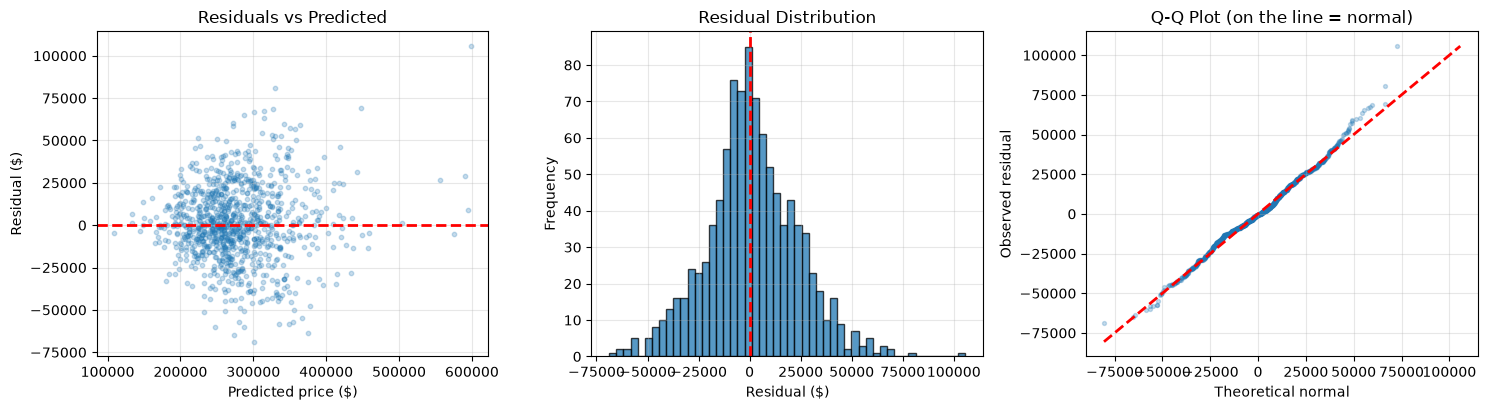

Residual mean = $  1,202.69   (০-এর কাছে থাকা উচিত)
Residual std  = $ 22,400.36   (≈ RMSE)
Residual skew =      0.1687   (|skew| < 0.5 হলে মোটামুটি symmetric)


In [16]:
# ---------------------------------------------------------------------------
# STEP 13: RESIDUAL ANALYSIS
# ---------------------------------------------------------------------------
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(y_pred, residuals, alpha=0.25, s=10)
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set(xlabel="Predicted price ($)", ylabel="Residual ($)",
            title="Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor="black", alpha=0.75)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set(xlabel="Residual ($)", ylabel="Frequency", title="Residual Distribution")

# Q-Q plot: normality-র সবচেয়ে সোজা চোখের পরীক্ষা
ordered = np.sort(residuals)
theoretical = np.sort(np.random.default_rng(RANDOM_STATE).normal(
    residuals.mean(), residuals.std(), len(residuals)))
axes[2].scatter(theoretical, ordered, alpha=0.25, s=8)
lims = [min(theoretical.min(), ordered.min()), max(theoretical.max(), ordered.max())]
axes[2].plot(lims, lims, "r--", linewidth=2)
axes[2].set(xlabel="Theoretical normal", ylabel="Observed residual",
            title="Q-Q Plot (on the line = normal)")

plt.tight_layout()
plt.show()

print(f"Residual mean = ${residuals.mean():>10,.2f}   (০-এর কাছে থাকা উচিত)")
print(f"Residual std  = ${residuals.std():>10,.2f}   (≈ RMSE)")
print(f"Residual skew = {pd.Series(residuals).skew():>11.4f}   (|skew| < 0.5 হলে মোটামুটি symmetric)")

### 6.15 Coefficient Interpretation — মডেল কী শিখল

**What we do:** coefficient-গুলো বের করে পড়ি — এবং একটা সাধারণ ফাঁদ ধরি।

**Why:** এখানেই লিনিয়ার রিগ্রেশনের আসল শক্তি। নিউরাল নেটওয়ার্ক বলতে পারে না "school_rating ১ বাড়লে দাম $৫,০২০ বাড়ে" — লিনিয়ার রিগ্রেশন পারে। ফাইনান্স, হেলথকেয়ার, লোন অ্যাপ্রুভালে এই ব্যাখ্যাটা আইনগতভাবে বাধ্যতামূলক।

> **⚠️ ফাঁদ:** "বড় coefficient = বেশি গুরুত্বপূর্ণ ফিচার" — এটা **ভুল**, যদি ফিচারগুলো unscaled হয়। coefficient-এর একক হলো "ফিচারের প্রতি ১ ইউনিটে কত ডলার", আর প্রতিটা ফিচারের ১ ইউনিট আলাদা জিনিস।

In [17]:
# ---------------------------------------------------------------------------
# STEP 14: READ THE COEFFICIENTS
# ---------------------------------------------------------------------------
coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_,
    "feature_std": X_train.std().values,
})
# coefficient × feature-এর std = "একটা সাধারণ মাপের পরিবর্তনে কত ডলার নড়ে"
# এটাই ফিচারগুলোকে একই রুলারে মাপার সৎ উপায়।
coef_table["impact_per_std"] = coef_table["coefficient"] * coef_table["feature_std"]
coef_table = coef_table.reindex(
    coef_table["impact_per_std"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

print(coef_table.to_string(index=False))
print()
print("তুলনা করুন দুইভাবে সাজালে কে উপরে ওঠে:")
by_coef = coef_table.reindex(coef_table["coefficient"].abs().sort_values(ascending=False).index)
print("  raw coefficient অনুযায়ী টপ ৩ :", list(by_coef["feature"].head(3)))
print("  impact_per_std অনুযায়ী টপ ৩  :", list(coef_table["feature"].head(3)))

          feature  coefficient  feature_std  impact_per_std
    median_income  40,481.1766       1.2243     49,559.4395
        avg_rooms  14,940.1730       1.5233     22,757.8341
 distance_to_city    -769.7483      14.9201    -11,484.7582
         has_pool  24,334.9316       0.4399     10,705.2492
    school_rating   5,020.5650       2.1083     10,584.9683
    garage_spaces   8,456.5892       0.9805      8,291.7376
     has_basement  13,588.7854       0.4904      6,663.4409
    lot_size_sqft       1.7462   1,822.8215      3,182.9438
        house_age    -106.5804      14.6204     -1,558.2443
       year_built     106.5804      14.6204      1,558.2443
    avg_occupancy    -342.1498       1.2130       -415.0329
     avg_bedrooms    -329.5544       0.4871       -160.5317
         latitude      48.5591       2.7111        131.6467
property_tax_rate     106.3388       0.3000         31.9035
       population       0.0116   2,169.7514         25.1057
        longitude       5.4104       3.0

In [18]:
# ---------------------------------------------------------------------------
# THE MULTICOLLINEARITY TRAP — দুইবার লেখা একই তথ্য
# ---------------------------------------------------------------------------
# house_age আর year_built আসলে একই ফ্যাক্ট: year_built = 2024 - house_age
print("house_age ও year_built-এর correlation =",
      round(df["house_age"].corr(df["year_built"]), 6))

pair = coef_table[coef_table["feature"].isin(["house_age", "year_built"])]
print()
print(pair[["feature", "coefficient"]].to_string(index=False))
print()
print("দুটো coefficient সমান-বিপরীত জোড়ায় এসেছে। মডেল জানেই না তথ্যটা কাকে দেবে,")
print("তাই সে যেকোনোভাবে ভাগ করে নেয়। প্রেডিকশন ঠিকই থাকে, কিন্তু কোনো একটা")
print("coefficient-কে আলাদাভাবে বিশ্বাস করা যায় না — এটাই multicollinearity।")
print()
print("সমাধান: দুটোর একটা বাদ দিন। নিচে প্রমাণ যে প্রেডিকশনের কোনো ক্ষতি হয় না —")

reduced = [f for f in feature_names if f != "year_built"]
model_reduced = LinearRegression().fit(X_train[reduced], y_train)
r2_reduced = r2_score(y_test, model_reduced.predict(X_test[reduced]))
print(f"  ১৬ ফিচারে R² = {r2_test:.6f}")
print(f"  ১৫ ফিচারে R² = {r2_reduced:.6f}   (পার্থক্য {abs(r2_test-r2_reduced):.2e})")

house_age ও year_built-এর correlation = -1.0

   feature  coefficient
 house_age    -106.5804
year_built     106.5804

দুটো coefficient সমান-বিপরীত জোড়ায় এসেছে। মডেল জানেই না তথ্যটা কাকে দেবে,
তাই সে যেকোনোভাবে ভাগ করে নেয়। প্রেডিকশন ঠিকই থাকে, কিন্তু কোনো একটা
coefficient-কে আলাদাভাবে বিশ্বাস করা যায় না — এটাই multicollinearity।

সমাধান: দুটোর একটা বাদ দিন। নিচে প্রমাণ যে প্রেডিকশনের কোনো ক্ষতি হয় না —
  ১৬ ফিচারে R² = 0.875420
  ১৫ ফিচারে R² = 0.875420   (পার্থক্য 3.33e-16)


### 6.16 Pipeline — প্রোডাকশনের সঠিক প্যাকেজিং

**What we do:** scaler আর model-কে একটা `Pipeline` অবজেক্টে বেঁধে ফেলি, তারপর ডিস্কে সেভ করি।

**Why:** প্রোডাকশনের সবচেয়ে কমন বাগ — নতুন ডেটা প্রেডিক্ট করার আগে scale করতে ভুলে যাওয়া। Pipeline এই ভুলটা **অসম্ভব** করে দেয়, কারণ `predict()` কল করলেই ভেতরে scaling নিজে থেকে হয়ে যায়।

**Analogy:** রোবট আর তার ক্যালিব্রেটেড কোর্ট-সেন্সর একসাথে একই বাক্সে প্যাক করা। আলাদা করে পাঠালে কেউ না কেউ সেন্সরটা বাসায় ফেলে আসবেই।

In [19]:
# ---------------------------------------------------------------------------
# STEP 15: THE DEPLOYABLE PIPELINE
# ---------------------------------------------------------------------------
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])

pipeline.fit(X_train, y_train)          # scaler.fit_transform + model.fit — এক কলে
pipe_pred = pipeline.predict(X_test)    # scaler.transform + model.predict — এক কলে

print(f"Pipeline R²        = {r2_score(y_test, pipe_pred):.6f}")
print(f"আলাদা model-এর R²  = {r2_test:.6f}")
print("একই ফলাফল — কারণ plain LinearRegression scaling-এ প্রভাবিত হয় না।")
print("লাভটা accuracy-তে নয়, লাভটা হলো ভুল করার সুযোগ বন্ধ হয়ে যাওয়ায়।\n")

# একটা নতুন বাড়ির জন্য প্রেডিকশন — raw, মানুষের বোধগম্য সংখ্যা দিয়ে
new_house = X_test.iloc[[0]]
print("নতুন একটা বাড়ি (raw feature, কোনো scaling ছাড়া):")
print(new_house[["median_income", "avg_rooms", "school_rating", "has_pool"]].to_string(index=False))
print(f"\n  Pipeline prediction = ${pipeline.predict(new_house)[0]:,.0f}")
print(f"  আসল দাম            = ${y_test.iloc[0]:,.0f}")

Pipeline R²        = 0.875420
আলাদা model-এর R²  = 0.875420
একই ফলাফল — কারণ plain LinearRegression scaling-এ প্রভাবিত হয় না।
লাভটা accuracy-তে নয়, লাভটা হলো ভুল করার সুযোগ বন্ধ হয়ে যাওয়ায়।

নতুন একটা বাড়ি (raw feature, কোনো scaling ছাড়া):
 median_income  avg_rooms  school_rating  has_pool
        2.1800     7.5000              8         1

  Pipeline prediction = $273,094
  আসল দাম            = $274,489


In [20]:
# ---------------------------------------------------------------------------
# SAVE & RELOAD — যেভাবে মডেল প্রোডাকশনে যায়
# ---------------------------------------------------------------------------
import joblib
import tempfile

# nb রান করলে repo নোংরা না হয়, তাই temp ফোল্ডারে সেভ করছি।
# আসল প্রজেক্টে এটাই যায় models/ ফোল্ডারে (দেখুন Class 1 Project/train_model.py)।
save_path = Path(tempfile.gettempdir()) / "class09_pipeline.pkl"
joblib.dump(pipeline, save_path)

loaded = joblib.load(save_path)
reloaded_pred = loaded.predict(new_house)[0]

print(f"সেভ হলো  : {save_path}")
print(f"রিলোড করে prediction = ${reloaded_pred:,.0f}")
assert np.isclose(reloaded_pred, pipeline.predict(new_house)[0])
print("\n✅ একটাই ফাইল = scaler + model। ডেপ্লয় করার জন্য এতটুকুই লাগে।")

সেভ হলো  : /var/folders/df/xvbb4c0j2zn25ysqm7jn_lw40000gn/T/class09_pipeline.pkl
রিলোড করে prediction = $273,094

✅ একটাই ফাইল = scaler + model। ডেপ্লয় করার জন্য এতটুকুই লাগে।


### 6.17 চূড়ান্ত রিভিউ: সব কিছু একসাথে

**What we do:** পুরো ওয়ার্কফ্লোটা একবারে চালিয়ে সংখ্যাগুলো এক জায়গায় দেখি।

**Why:** ইন্টারভিউতে "আপনার রিগ্রেশন ওয়ার্কফ্লো বলুন" জিজ্ঞেস করলে এই ৫ ধাপই উত্তর।

In [21]:
# ---------------------------------------------------------------------------
# STEP 16: THE WHOLE WORKFLOW IN ONE PLACE
# ---------------------------------------------------------------------------
# 1. Split  2. Scale (train-এ fit)  3. Train  4. Evaluate  5. Interpret & deploy
final = Pipeline([("scaler", StandardScaler()), ("regressor", LinearRegression())])
final.fit(X_train, y_train)
final_pred = final.predict(X_test)

report = pd.DataFrame([{
    "n_train": len(X_train),
    "n_test": len(X_test),
    "n_features": len(feature_names),
    "RMSE": np.sqrt(mean_squared_error(y_test, final_pred)),
    "MAE": mean_absolute_error(y_test, final_pred),
    "R2": r2_score(y_test, final_pred),
    "MAPE_%": np.mean(np.abs((y_test - final_pred) / y_test)) * 100,
}])
print(report.to_string(index=False))
print()
print("টপ ৫ প্রাইস ড্রাইভার (একটা সাধারণ মাপের পরিবর্তনে কত ডলার):")
for _, row in coef_table.head(5).iterrows():
    arrow = "↑" if row["impact_per_std"] > 0 else "↓"
    print(f"  {arrow} {row['feature']:<18} ${abs(row['impact_per_std']):>9,.0f}")

 n_train  n_test  n_features        RMSE         MAE     R2  MAPE_%
    4000    1000          16 22,432.6188 17,077.2174 0.8754  6.1824

টপ ৫ প্রাইস ড্রাইভার (একটা সাধারণ মাপের পরিবর্তনে কত ডলার):
  ↑ median_income      $   49,559
  ↑ avg_rooms          $   22,758
  ↓ distance_to_city   $   11,485
  ↑ has_pool           $   10,705
  ↑ school_rating      $   10,585


---

## 7. Class 9 Learning Objectives — চেক করুন

এই সেশন শেষে আপনি যা যা পারবেন:

1. ✅ লিনিয়ার রিগ্রেশন ইকুয়েশন **ব্যাখ্যা করতে পারবেন** এবং বিজনেস কনটেক্সটে প্রতিটি কো-এফিশিয়েন্টের অর্থ বের করতে পারবেন → *Step 14*
2. ✅ স্ক্র্যাচ থেকে গ্র্যাডিয়েন্ট ডিসেন্ট **ইমপ্লিমেন্ট করতে পারবেন** → *Step 5*
3. ✅ MSE, RMSE, MAE ক্যালকুলেট ও **ইন্টারপ্রেট করতে পারবেন** → *Step 12*
4. ✅ ট্রেন/টেস্ট বাউন্ডারি ঠিক রেখে `StandardScaler` ও `MinMaxScaler` **অ্যাপ্লাই করতে পারবেন** → *Step 8, 10*
5. ✅ `sklearn.pipeline.Pipeline` দিয়ে কমপ্লিট রিগ্রেশন পাইপলাইন **তৈরি করতে পারবেন** → *Step 15*
6. ✅ রেসিডুয়াল অ্যানালিসিস করে মডেলের সমস্যা **ডায়াগনোস করতে পারবেন** → *Step 13*

---

## 8. Key Takeaways

> 📌 **Linear regression is the Rosetta Stone of ML.** পরে যত অ্যালগরিদমই শিখুন — লজিস্টিক রিগ্রেশন, নিউরাল নেটওয়ার্ক, SVM — সবাই একই কাজ করে: একটা লস ফাংশন মিনিমাইজ করার জন্য সেরা প্যারামিটার খোঁজা। এই প্যাটার্ন ধরতে পারলে মেশিন লার্নিংয়ের ৮০% আপনার কবজায়।

> 📌 **MSE punishes arrogance.** error স্কয়ার হয় বলে আত্মবিশ্বাসের সাথে দেওয়া বড় ভুলের দাম চড়া। মডেল বাধ্য হয় বড় ভুলগুলো আগে ঠিক করতে।

> 📌 **Gradient descent is universal.** ২টা কো-এফিশিয়েন্ট টিউন করুন বা GPT-এর ১৭৫ বিলিয়ন প্যারামিটার — অ্যালগরিদম একই: gradient বের করো, এক কদম আগাও, রিপিট করো।

> 📌 **Feature scaling is not optional.** Step 7-এ নিজের চোখে দেখলেন — একই কোড, একই α, শুধু স্কেলের পার্থক্যে একটা কনভার্জ করল আর একটা বিস্ফোরিত হলো।

> 📌 **Always use Pipelines.** প্রেডিকশনের আগে নতুন ডেটা scale করতে ভুলে যাওয়া — প্রোডাকশনের সবচেয়ে কমন বাগ। Pipeline সেই ভুলটাই অসম্ভব করে দেয়।

---

## 9. এরপর কী

👉 **Week 5 / Class 1 Project** (`../Class 1 Project/`) — এই নোটবুকের প্রতিটা কনসেপ্ট ওখানে একটা ইন্টারঅ্যাকটিভ Streamlit dashboard হয়ে আছে:

```bash
cd "../Class 1 Project"
python3 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
streamlit run app.py
```

| এই নোটবুকের ধাপ | Dashboard-এর যে page-এ |
| --- | --- |
| Step 2–4 (data, MSE কার্ভ) | 📊 Explore Data, 📐 Model Theory |
| Step 5–7 (GD, learning rate, scaling) | 📉 Gradient Descent |
| Step 8 (scaler তুলনা) | ⚖️ Feature Scaling |
| Step 12–13 (metrics, residual) | 📏 Model Evaluation |
| Step 14–15 (coefficient, pipeline) | 🔮 Predict Price |

---

## 10. Recommended Reading

* *"Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow"* — Aurélien Géron (Ch. 4–5)
* *"An Introduction to Statistical Learning"* — James, Witten, Hastie & Tibshirani (Ch. 3)
* *"The Elements of Statistical Learning"* — Hastie, Tibshirani & Friedman (Ch. 3, গভীর থিওরি)
* **Scikit-Learn docs:** `LinearRegression`, `StandardScaler`, `Pipeline`
* **Interactive:** [Géron-এর companion repo](https://github.com/ageron/handson-ml3)